In [1]:
import numpy as np
import pandas as pd
#import umap
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq

#from muon import prot as pt
from sklearn import preprocessing
import os
import itertools
import sys
sys.path.append('../phenotyping/')
from collections import defaultdict
from tqdm import tqdm
import seaborn as sns
input_dir = 'pre_processed_files/'
output_fig = '../figures'
def strip_extension(self):
    '''strip the file extension from a pd.Series of file names'''
    return self.apply(lambda x: os.path.splitext(x)[0])

from phenotyping_utils import generate_anndata_from_ark_analysis
# Add the method to the Pandas Series class
pd.Series.strip_extension = strip_extension
%matplotlib inline

In [2]:
!ls 

Carboplatin_acquisition_ID.csv		    fiber_segmentation_processed_data
__pycache__				    figures
cell_neighbors_analysis.ipynb		    neighbours_matrix.pkl
data					    non_spatial.ipynb
distance_distribution.pkl		    prova.png
distance_distribution.py		    spatial.ipynb
example_neighborhood_analysis_script.ipynb  visualise_cell_annotation.ipynb
fiber_segmentation.ipynb


In [3]:
adata = generate_anndata_from_ark_analysis(cell_table_path='../../segmentation/cell_table_Denoised/cell_table_size_normalized_cell_labels.csv',biosamples_path='../../IMC_data/ExtraDocs/processed_response.csv')

/home/giuseppe/anaconda3/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


read intensities ( protein level per cell)

N. of cells by experiments, for the rest of the analysis, we discard samples with less than a 1000 cells

few fovs have all cell types

In [6]:
a = adata.obs[['Leap_ID','SAMPLE_TYPE_(CORE/RESECTION)','Response']]
a.drop_duplicates().Response.value_counts()
#a.drop_duplicates()['SAMPLE_TYPE_(CORE/RESECTION)'].value_counts()

Response
Non-Responder    63
pCR              28
Name: count, dtype: int64

## Inspecting the cell annotation

In [9]:
core = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE'].copy()
resection = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION'].copy()

# Spatial Analysis
### neighbours

For every acquisition_ID, the neighbourhood enrichment is computed. To compute the average,  for every pair of labels, the z-score are added and divided by the number of fovs that contains the 2 labels.

In [4]:
import pickle

In [ ]:
###DO NOT RUN if unsure. IT takes ages
def neighbours(fovs):
    labels_list = adata.obs.Pixie.unique()
    enrich_matrix = pd.DataFrame(0,index = labels_list,columns=labels_list)
    denominator =  pd.DataFrame(0,index = labels_list,columns=labels_list)
    
    for ID in  set(fovs):
        sub_adata = adata[adata.obs.acquisition_ID==ID]#select one acquisition
        sq.gr.spatial_neighbors(sub_adata,coord_type='grid')
        sq.gr.nhood_enrichment(sub_adata, cluster_key='Pixie')
        A = sub_adata.uns['Pixie_nhood_enrichment']['zscore']
        a = np.array(sub_adata.obs['Pixie'].cat.categories)#label list
        fov_neighbour = pd.DataFrame(A,index=a,columns=a)
        enrich_matrix.loc[a,a]+=fov_neighbour.fillna(0)
        temp_denominator = pd.DataFrame(1,index = a,columns = a)
        temp_denominator.mask(fov_neighbour.isna(),0)
        #print(np.diag(enrich_matrix))
        denominator.loc[a,a]+=temp_denominator
    neigb_tb = enrich_matrix/denominator
    #v = neigb_tb.loc[neigb_tb.index,neigb_tb.index].values
    return neigb_tb
core = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)'] == 'CORE']
resection = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)'] == 'RESECTION']

'''
neigh_pcR = neighbours(core[core.obs.Response=='pCR'].obs.acquisition_ID)
neigh_nR = neighbours(core[core.obs.Response=='Non-Responder'].obs.acquisition_ID)
#neigh_res = neighbours(resection.obs.acquisition_ID)

with open('neighbours_matrix.pkl', 'wb') as f:
    pickle.dump({'resection':neigh_res,'pCR':neigh_pcR,'non_responder':neigh_nR}, f)
'''

In [61]:
###DO NOT RUN if unsure. Data are saved
def neighbours(fovs):
    store = {}    
    for ID in  set(fovs):
        sub_adata = adata[adata.obs.acquisition_ID==ID]#select one acquisition
        sq.gr.spatial_neighbors(sub_adata,coord_type='grid')
        sq.gr.nhood_enrichment(sub_adata, cluster_key='Pixie')
        A = sub_adata.uns['Pixie_nhood_enrichment']['zscore']
        a = np.array(sub_adata.obs['Pixie'].cat.categories)#label list
        fov_neighbour = pd.DataFrame(A,index=a,columns=a)
        store[ID]=fov_neighbour.fillna(0)
    return store
#core = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)'] == 'CORE']
#resection = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)'] == 'RESECTION']
neigh_all = neighbours(adata.obs.acquisition_ID.drop_duplicates())
with open('neighbours_matrix.pkl', 'wb') as f:
    pickle.dump(neigh_all, f)


/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:198: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data


  0%|          | 0/1000 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_nhood.py:188: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)
/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:198: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data


  0%|          | 0/1000 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_nhood.py:188: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)
/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:198: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data


...

/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_nhood.py:188: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)
/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:198: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data


  0%|          | 0/1000 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_nhood.py:188: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)
/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_utils.py:198: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data


  0%|          | 0/1000 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.9/site-packages/squidpy/gr/_nhood.py:188: RuntimeWarning: invalid value encountered in divide
  zscore = (count - perms.mean(axis=0)) / perms.std(axis=0)


In [5]:


with open('neighbours_matrix.pkl', 'rb') as f:
    neigh_all = pickle.load(f)

In [178]:
labels_list = adata.obs.Pixie.unique()
X = []
y = []
core_ids = set(core.obs.acquisition_ID)
for id,tb in neigh_all.items():
    if id not in core_ids:
        continue
    temp_matrix = pd.DataFrame(0,index = labels_list,columns=labels_list)
    sub_list = tb.index#label list
    tb.replace([np.inf, -np.inf], np.nan, inplace=True) # convert inf to nan, next line everything is replaced with 0
    temp_matrix.loc[sub_list,sub_list]=tb
    temp_values = temp_matrix.values
    X +=[temp_values]
    y+=[id]
y = np.vectorize(dict(core.obs[['acquisition_ID','Response']].values).get)(y)
X = np.array(X)


0.8100280370509856

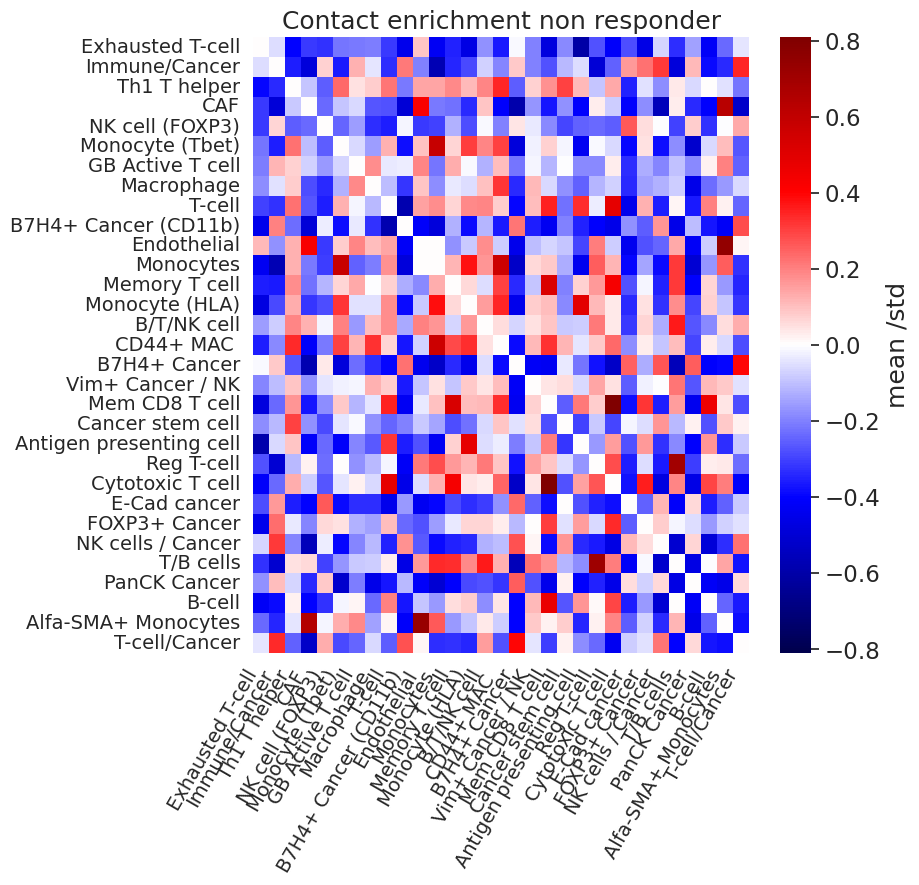

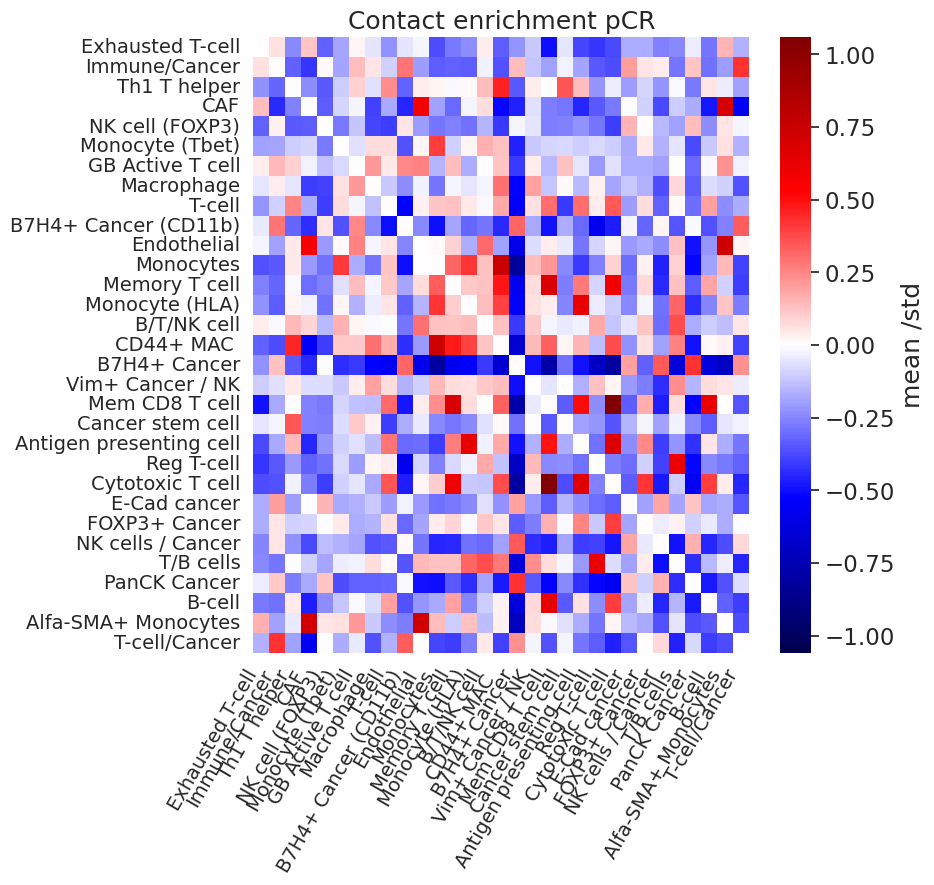

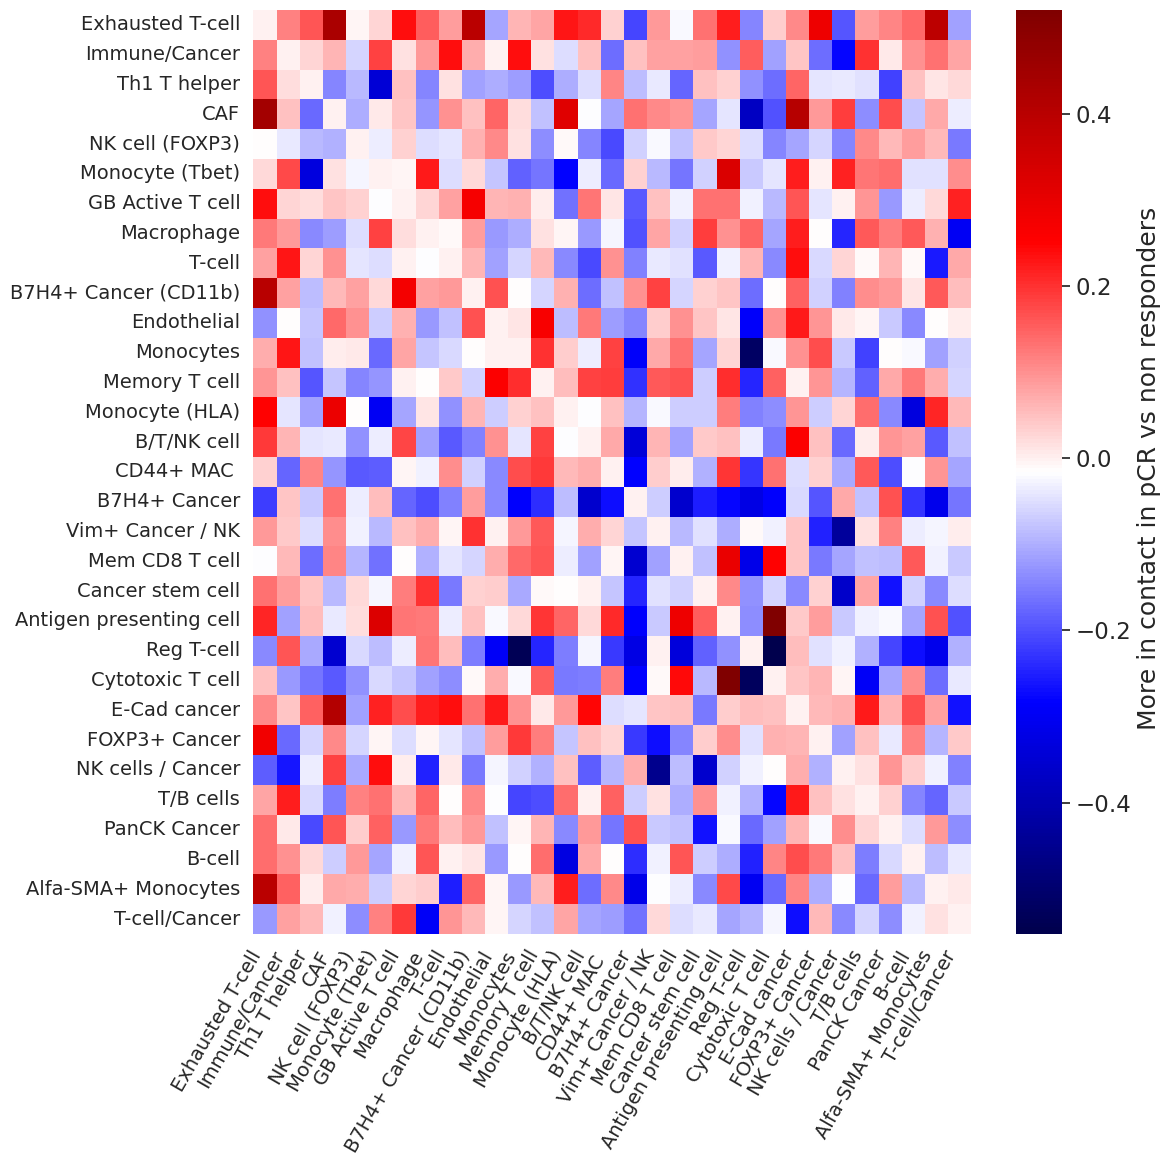

In [919]:

#axs[2].sharey(axs[1])
#axs[0].get_shared_y_axes().join(axs[1],axs[2])

aux = X[y == 'Non-Responder']
mean_nR = pd.DataFrame(np.nanmean(aux,axis = 0)/np.nanstd(aux,axis = 0),index = labels_list,columns=labels_list)

np.fill_diagonal(mean_nR.values,0)
aux = X[y == 'pCR']
mean_pCr = pd.DataFrame(np.nanmean(aux,axis = 0)/np.nanstd(aux,axis = 0),index = labels_list,columns=labels_list)
np.fill_diagonal(mean_pCr.values,0)
plt.figure(figsize = (8,8))
plt.title('Contact enrichment non responder')
vmax = mean_nR.abs().to_numpy().max()
sns.heatmap(mean_nR,cmap='seismic',xticklabels=True,yticklabels=True,vmin = -vmax,vmax = vmax,cbar = True,cbar_kws={'label':'mean /std'})
_ = plt.xticks(rotation=60,fontsize = 14,ha='right')
_ = plt.yticks(fontsize = 14)
plt.figure(figsize = (8,8))
plt.title('Contact enrichment pCR')
vmax = mean_pCr.abs().to_numpy().max()
sns.heatmap(mean_pCr,cmap='seismic',xticklabels=True,yticklabels=True,cbar =True,vmin = -vmax,vmax = vmax,cbar_kws={'label':'mean /std'})
_ = plt.xticks(rotation=60,fontsize = 14,ha='right')
_ = plt.yticks(fontsize = 14)
plt.figure(figsize = (12,12))

sns.heatmap(mean_pCr-mean_nR,cmap='seismic',xticklabels=True,yticklabels=True,cbar = True,cbar_kws={'label':' More in contact in pCR vs non responders'})
_ = plt.xticks(rotation=60,fontsize = 14,ha='right')
_ = plt.yticks(fontsize = 14)
plt.tight_layout()
#plt.savefig('../figures/spatial/neigh_diff_response.png')

In [926]:
np.argmax((mean_pCr-mean_nR).to_numpy())

702

We now train a calissifier that, for each fov, it computes the contanct matrix enrichment, and uses it to predict response.The features that have more weight in the decision are postulated to have a biological importance

In [837]:
from sklearnex import patch_sklearn
from sklearn.linear_model import LogisticRegression
#from cuml.linear_model import LogisticRegression cuml does not work for multiclass regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV,cross_val_score

In [859]:
max_abs_scaler = preprocessing.MaxAbsScaler()
scaler = preprocessing.StandardScaler(with_mean = False)
le = LabelEncoder()
pca = PCA(n_components=20)
y_num = le.fit_transform(y)

clip_value = 3
X_num = np.array([((x+x.T)/2)[np.triu_indices(len(labels_list),k = 1)] for x in X])
X_num[np.isnan(X_num)] = 0# I don't know why there are nan, as this contains off diagonal terms.

X_num = scaler.fit_transform(X_num)
X_num = np.clip(X_num,-clip_value,clip_value)
#X_num = pca.fit_transform(X_num)
X_train, X_test, y_train, y_test = train_test_split(X_num, y_num, test_size=0.33, random_state=42)
#X_test = np.clip(X_test,-clip_value,clip_value)#scaler.fit_transform(X_test)
#X_train = np.clip(X_train,-clip_value,clip_value)#scaler.fit_transform(X_train)

le.inverse_transform([0,1])

array(['Non-Responder', 'pCR'], dtype='<U13')

In [861]:
clf = LogisticRegression(solver = 'newton-cg',class_weight='balanced',penalty = 'l2',C = 0.5,verbose=2).fit(X = X_train, y = y_train)
y_pred = clf.predict(X_test)
print(accuracy_score(y_train, clf.predict(X_train)),balanced_accuracy_score(y_train, clf.predict(X_train)))
print(accuracy_score(y_test, y_pred),balanced_accuracy_score(y_test, y_pred))

0.7040816326530612 0.7015654648956356
0.7034482758620689 0.7031785306433194


In [862]:
C_s_2_inspect = list(map(lambda x:x[0]*x[1], itertools.product([1e-4,1e-3,1e-2,1e-1,1,10],[1,5])))
tuned_parameters = [
    { 'class_weight':['balanced'],"C": C_s_2_inspect},
]

grid_search = GridSearchCV(
    LogisticRegression(), tuned_parameters,
)
grid_search.fit(X_num, y_num)
clf = grid_search.best_estimator_

In [863]:
clf

LogisticRegression(C=0.005, class_weight='balanced')

In [864]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_class_weight,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003052,0.000375,0.000610,0.000074,0.0001,balanced,"{'C': 0.0001, 'class_weight': 'balanced'}",0.738636,0.693182,0.693182,0.647727,0.655172,0.685580,0.032521,11
1,0.002088,0.000055,0.000430,0.000001,0.0005,balanced,"{'C': 0.0005, 'class_weight': 'balanced'}",0.750000,0.693182,0.681818,0.659091,0.643678,0.685554,0.036549,12
2,0.002034,0.000093,0.000432,0.000016,0.001,balanced,"{'C': 0.001, 'class_weight': 'balanced'}",0.772727,0.693182,0.704545,0.681818,0.643678,0.699190,0.042085,8
3,0.003651,0.001823,0.000639,0.000262,0.005,balanced,"{'C': 0.005, 'class_weight': 'balanced'}",0.761364,0.772727,0.704545,0.693182,0.632184,0.712800,0.050797,1
4,0.002999,0.000608,0.000553,0.000140,0.01,balanced,"{'C': 0.01, 'class_weight': 'balanced'}",0.761364,0.738636,0.704545,0.715909,0.632184,0.710528,0.043765,2
5,0.002197,0.000068,0.000409,0.000019,0.05,balanced,"{'C': 0.05, 'class_weight': 'balanced'}",0.738636,0.772727,0.625000,0.693182,0.655172,0.696944,0.053696,10
6,0.002182,0.000078,0.000407,0.000002,0.1,balanced,"{'C': 0.1, 'class_weight': 'balanced'}",0.738636,0.795455,0.625000,0.670455,0.666667,0.699242,0.060350,3
7,0.002333,0.000168,0.000413,0.000018,0.5,balanced,"{'C': 0.5, 'class_weight': 'balanced'}",0.738636,0.784091,0.636364,0.670455,0.666667,0.699242,0.054027,3
8,0.002307,0.000120,0.000414,0.000018,1,balanced,"{'C': 1, 'class_weight': 'balanced'}",0.738636,0.772727,0.636364,0.670455,0.666667,0.696970,0.050537,9
9,0.002251,0.000139,0.000409,0.000017,5,balanced,"{'C': 5, 'class_weight': 'balanced'}",0.738636,0.772727,0.636364,0.681818,0.666667,0.699242,0.049539,5


In [842]:
clf = RandomForestClassifier(max_depth=5).fit(X = X_train, y = y_train)
y_pred = clf.predict(X_test)
print(accuracy_score(y_train, clf.predict(X_train)),balanced_accuracy_score(y_train, clf.predict(X_train)))
print(accuracy_score(y_test, y_pred),balanced_accuracy_score(y_test, y_pred))

0.9795918367346939 0.9758064516129032
0.7172413793103448 0.7215454891511229


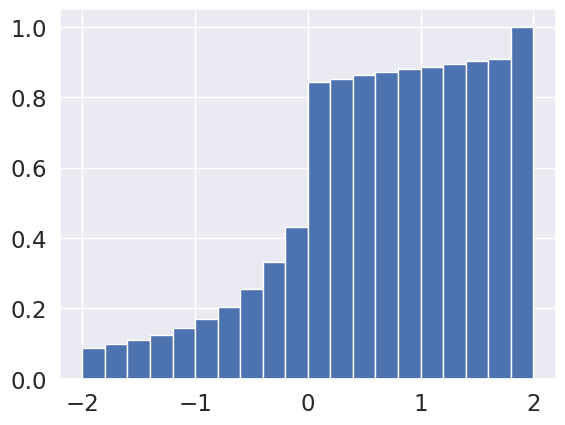

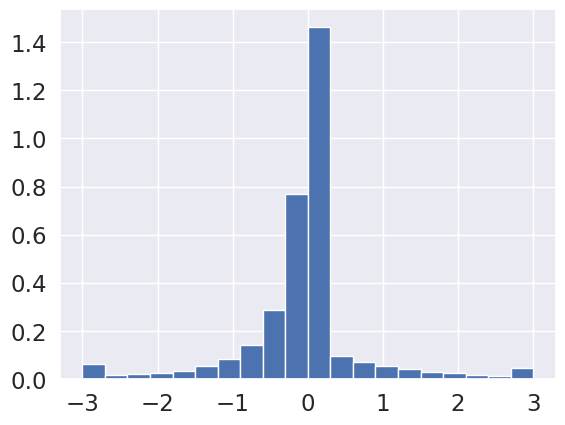

In [522]:
_ = plt.hist(np.clip(X,-2,2).reshape(-3),bins = 20,cumulative=True,density=True)
plt.figure()
_ = plt.hist(X_train.reshape(-1),bins = 20,density=True)

<Axes: ylabel='Count'>

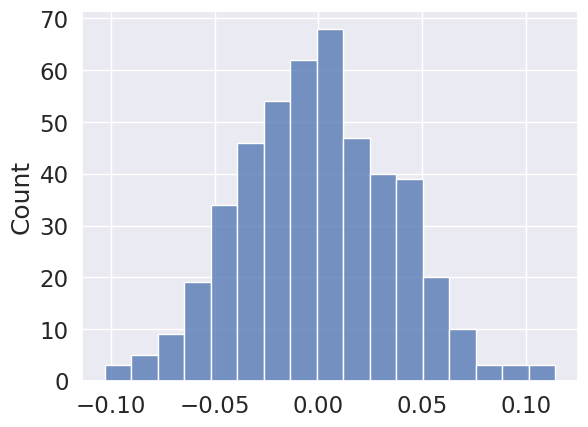

In [523]:
sns.histplot(*clf.coef_)


<Axes: >

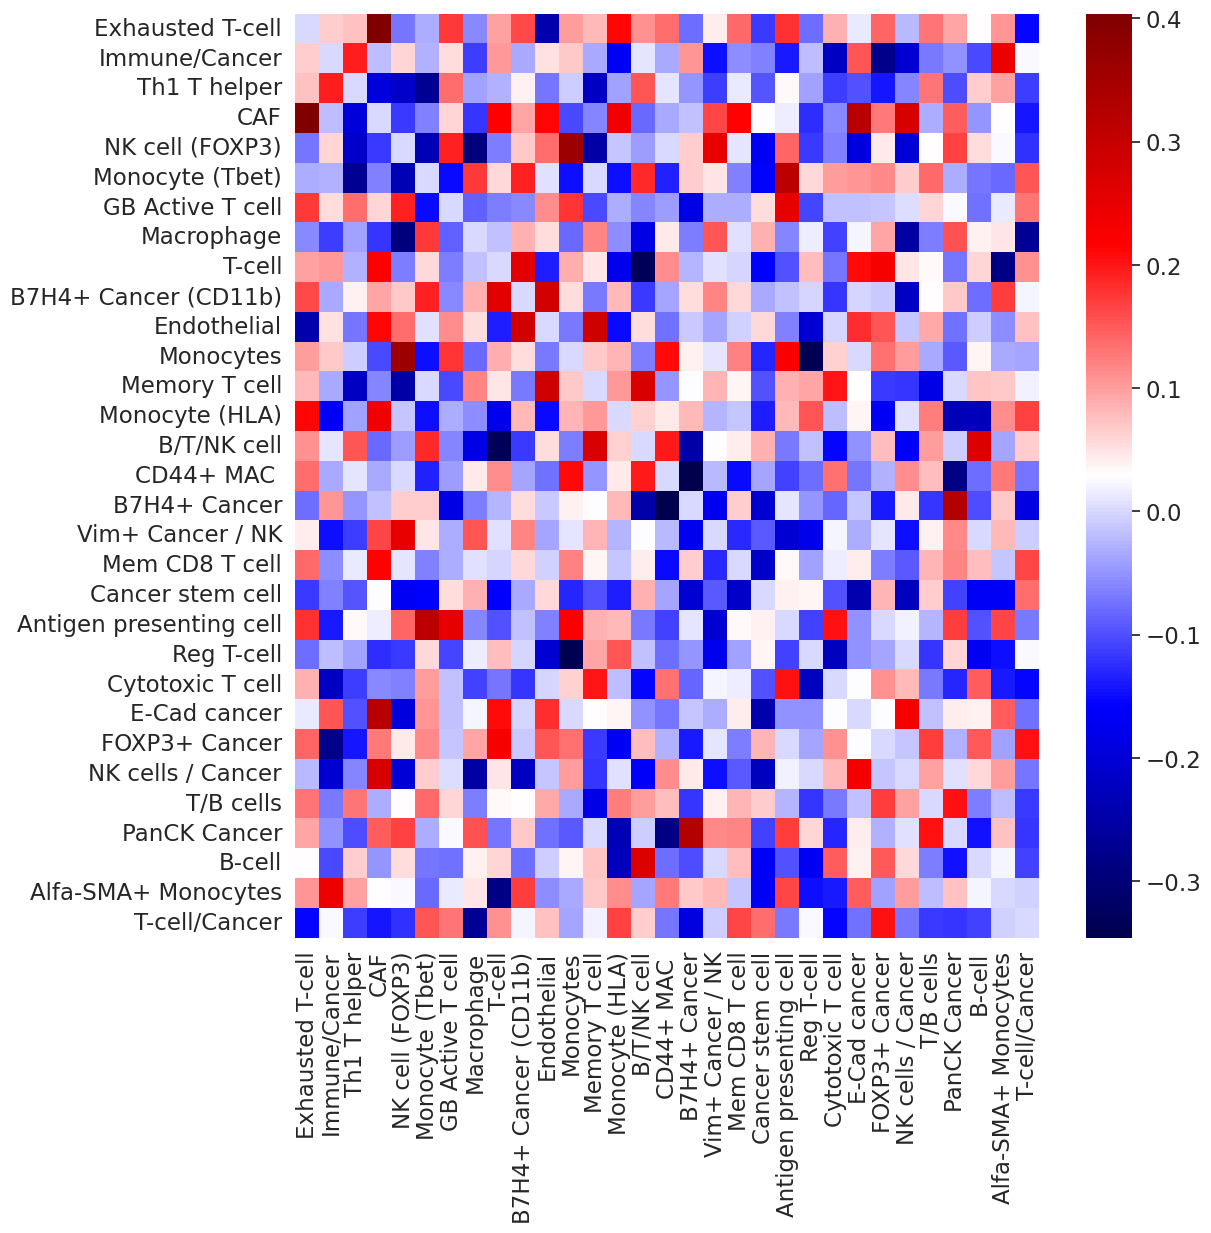

In [728]:
weight_importance  = np.zeros((len(labels_list),len(labels_list)))
weight_importance[np.triu_indices(len(labels_list),k = 1)] = np.squeeze(clf.coef_)#fill the values of upper triangular
weight_importance[np.triu_indices(len(labels_list),k = 1)[::-1]] = np.squeeze(clf.coef_)#fill the values of the lower triangular
weight_importance = pd.DataFrame(weight_importance,columns=labels_list,index=labels_list)
plt.figure(figsize = (12,12))
sns.heatmap(weight_importance,cmap='seismic')

In [729]:
top_features = np.squeeze(np.argsort(np.abs(clf.coef_)))[::-1]#features sorted by their importance in logistic regression 

a = list(zip(*labels_list[np.array(np.triu_indices(len(labels_list),k = 1))[:,top_features]],np.squeeze(clf.coef_)[top_features]))
interpret_lr = pd.DataFrame(a,columns = ['from','top','weight']).iloc[:10]
#positive weights means that it help response
interpret_lr['prediction_towards'] = interpret_lr.weight.apply(lambda x:'pCR' if x>0 else 'Non responder')
#interpret_lr.to_latex()
interpret_lr

,from,top,weight,prediction_towards
0,Exhausted T-cell,CAF,0.403767,pCR
1,NK cell (FOXP3),Monocytes,0.360583,pCR
2,CD44+ MAC,B7H4+ Cancer,-0.345868,Non responder
3,Monocytes,Reg T-cell,-0.339817,Non responder
4,T-cell,B/T/NK cell,-0.331681,Non responder
5,B7H4+ Cancer,PanCK Cancer,0.325281,pCR
6,CAF,E-Cad cancer,0.319733,pCR
7,Monocyte (Tbet),Antigen presenting cell,0.313569,pCR
8,NK cell (FOXP3),Macrophage,-0.295029,Non responder
9,Endothelial,Memory T cell,0.287843,pCR


In [902]:

mean_all = pd.DataFrame(np.nanmean(X,axis = 0)/np.nanstd(X,axis  = 0),index = labels_list,columns=labels_list)

np.fill_diagonal(mean_all.values,0)

#sns.heatmap(mean_all,cmap='seismic',xticklabels=True,yticklabels=True,vmin = -5,vmax = 5,cbar = False)
import networkx as nx



In [911]:
mean_all

,Exhausted T-cell,Immune/Cancer,Th1 T helper,CAF,NK cell (FOXP3),Monocyte (Tbet),GB Active T cell,Macrophage,T-cell,B7H4+ Cancer (CD11b),...,Reg T-cell,Cytotoxic T cell,E-Cad cancer,FOXP3+ Cancer,NK cells / Cancer,T/B cells,PanCK Cancer,B-cell,Alfa-SMA+ Monocytes,T-cell/Cancer
Exhausted T-cell,0.000000,0.009277,-0.300488,-0.153783,-0.327607,-0.171704,-0.103479,-0.114487,-0.244204,-0.244273,...,-0.273859,-0.353024,-0.213758,-0.316690,-0.152112,-0.258345,-0.077909,-0.349590,-0.105894,-0.094280
Immune/Cancer,0.014102,0.000000,-0.340326,-0.437731,0.046699,-0.265257,0.132609,0.018871,-0.186755,0.242250,...,-0.387080,-0.301788,0.183065,0.129279,0.187424,-0.363254,0.117088,-0.302303,-0.270188,0.380851
Th1 T helper,-0.288396,-0.324813,0.000000,-0.162899,-0.298424,0.034824,0.071281,0.011716,0.225295,-0.250528,...,-0.167088,0.038073,-0.262647,-0.069412,-0.192976,0.008927,-0.176144,0.033730,-0.040409,-0.193486
CAF,-0.145842,-0.447566,-0.171962,0.000000,-0.277082,-0.087867,-0.040532,-0.335423,-0.226258,-0.446873,...,-0.207922,-0.195325,-0.227297,-0.128505,-0.444841,-0.039323,-0.217350,-0.450597,0.667860,-0.541917
NK cell (FOXP3),-0.319896,0.048803,-0.298368,-0.276823,0.000000,-0.265237,-0.122697,-0.361561,-0.375686,0.025344,...,-0.264621,-0.290644,0.201325,0.019152,-0.104946,-0.238020,0.111804,-0.277578,0.034086,0.069019
Monocyte (Tbet),-0.170966,-0.264786,0.028023,-0.094251,-0.266894,0.000000,-0.054282,-0.023056,0.097441,-0.358143,...,-0.057181,-0.075458,-0.289370,0.046086,-0.238439,-0.117129,-0.418060,-0.080327,0.080799,-0.204271
GB Active T cell,-0.091983,0.134652,0.081897,-0.053034,-0.125316,-0.063009,0.000000,0.191815,0.015350,0.134390,...,-0.175738,-0.015102,-0.227368,-0.153251,-0.188155,-0.037551,-0.212517,0.004884,0.209554,-0.071300
Macrophage,-0.103922,0.007489,0.009518,-0.346983,-0.368368,-0.020077,0.196025,0.000000,-0.110139,-0.276215,...,-0.016991,-0.141692,-0.194342,-0.151890,-0.272920,0.033235,-0.363514,-0.116967,-0.119026,-0.248141
T-cell,-0.239347,-0.183983,0.237278,-0.219445,-0.374593,0.095984,-0.019844,-0.117682,0.000000,-0.549307,...,0.017851,0.399011,-0.321197,0.095847,-0.330663,0.012021,-0.307687,0.194517,-0.110764,-0.183071
B7H4+ Cancer (CD11b),-0.238347,0.237947,-0.257052,-0.438652,0.019436,-0.354865,0.128262,-0.283206,-0.537912,0.000000,...,-0.473148,-0.457585,-0.093118,-0.294105,0.094610,-0.396249,-0.067957,-0.360208,-0.337286,0.307148


In [756]:
from adjustText import adjust_text

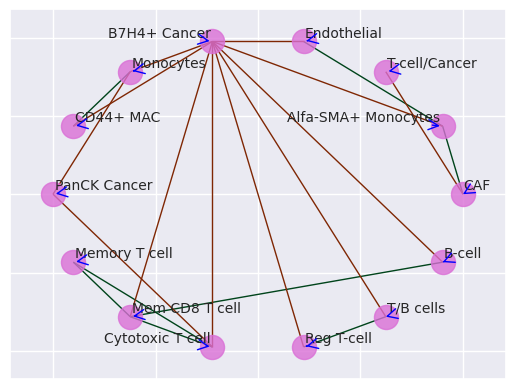

In [918]:
def create_corr_network(enrichment,  min_correlation,graphical = False):
    G = nx.from_numpy_array(enrichment.values)
    G = nx.relabel_nodes(G,lambda x: list(enrichment.columns)[x])
    ...
    source, to, weight = zip(*G.edges(data = True))
    weight = np.array([w['weight']for w in weight])
    cond = np.abs(weight)>min_correlation
    source, to, weight = np.stack((source, to, weight),axis = 1)[cond].T
    H = nx.Graph()
    

    H.add_weighted_edges_from(np.stack((source, to, weight),axis = 1),data = True)
    return H
def draw_network(G,node):
    G.remove_edges_from(nx.selfloop_edges(G))
    G = nx.ego_graph(G,n = node,radius = 3)
    source, to, weight = zip(*G.edges(data = True))
    weight = np.array([w['weight']for w in weight]).astype(float)
    #positions
    positions=nx.circular_layout(G)
    weight_colours = tuple([(1+abs(x))**2 for x in weight])
    nx.draw_networkx_nodes(G,pos = positions,node_color='#DA70D6',nodelist=G.nodes(),
                           #####the node size will be now based on its degree
                           alpha=0.8)
    edgelist = np.array(list(G.edges()))
    cond = weight>0
    width = 1
    
    nx.draw_networkx_edges(G,edgelist= edgelist[cond],pos = positions,style='solid',
                          ###adds width=weights and edge_color = weights 
                          ###so that edges are based on the weight parameter 
                          ###edge_cmap is for the color scale based on the weight
                          ### edge_vmin and edge_vmax assign the min and max weights for the width
                          width= width, edge_color = np.array(weight_colours)[cond],edge_cmap  = plt.cm.Greens, 
                          edge_vmin = min(weight), edge_vmax=max(weight))
    cond = weight<0
    nx.draw_networkx_edges(G,edgelist= edgelist[cond],pos = positions,style='solid',
                          ###adds width=weights and edge_color = weights 
                          ###so that edges are based on the weight parameter 
                          ###edge_cmap is for the color scale based on the weight
                          ### edge_vmin and edge_vmax assign the min and max weights for the width
                          width=width, edge_color = np.array(weight_colours)[cond],edge_cmap  = plt.cm.Oranges, 
                          edge_vmin = min(weight), edge_vmax=max(weight))
    #Styling for labels
    #nx.draw_networkx_labels(H, positions, font_size=8, 
    #                            font_family='sans-serif')
    b = [plt.annotate(text,positions[text]*1,fontsize = 10) for text in list(G.nodes)]
    adjust_text(b, arrowprops=dict(arrowstyle='->', color='blue'))

#H = create_corr_network(pd.DataFrame(X[0],index = labels_list,columns=labels_list),  min_correlation = 2.5,graphical = True)
H = create_corr_network(mean_all,  min_correlation = .5,graphical = True)
draw_network(H,node = 'B7H4+ Cancer')

In [915]:
mean_all

,Exhausted T-cell,Immune/Cancer,Th1 T helper,CAF,NK cell (FOXP3),Monocyte (Tbet),GB Active T cell,Macrophage,T-cell,B7H4+ Cancer (CD11b),...,Reg T-cell,Cytotoxic T cell,E-Cad cancer,FOXP3+ Cancer,NK cells / Cancer,T/B cells,PanCK Cancer,B-cell,Alfa-SMA+ Monocytes,T-cell/Cancer
Exhausted T-cell,0.000000,0.009277,-0.300488,-0.153783,-0.327607,-0.171704,-0.103479,-0.114487,-0.244204,-0.244273,...,-0.273859,-0.353024,-0.213758,-0.316690,-0.152112,-0.258345,-0.077909,-0.349590,-0.105894,-0.094280
Immune/Cancer,0.014102,0.000000,-0.340326,-0.437731,0.046699,-0.265257,0.132609,0.018871,-0.186755,0.242250,...,-0.387080,-0.301788,0.183065,0.129279,0.187424,-0.363254,0.117088,-0.302303,-0.270188,0.380851
Th1 T helper,-0.288396,-0.324813,0.000000,-0.162899,-0.298424,0.034824,0.071281,0.011716,0.225295,-0.250528,...,-0.167088,0.038073,-0.262647,-0.069412,-0.192976,0.008927,-0.176144,0.033730,-0.040409,-0.193486
CAF,-0.145842,-0.447566,-0.171962,0.000000,-0.277082,-0.087867,-0.040532,-0.335423,-0.226258,-0.446873,...,-0.207922,-0.195325,-0.227297,-0.128505,-0.444841,-0.039323,-0.217350,-0.450597,0.667860,-0.541917
NK cell (FOXP3),-0.319896,0.048803,-0.298368,-0.276823,0.000000,-0.265237,-0.122697,-0.361561,-0.375686,0.025344,...,-0.264621,-0.290644,0.201325,0.019152,-0.104946,-0.238020,0.111804,-0.277578,0.034086,0.069019
Monocyte (Tbet),-0.170966,-0.264786,0.028023,-0.094251,-0.266894,0.000000,-0.054282,-0.023056,0.097441,-0.358143,...,-0.057181,-0.075458,-0.289370,0.046086,-0.238439,-0.117129,-0.418060,-0.080327,0.080799,-0.204271
GB Active T cell,-0.091983,0.134652,0.081897,-0.053034,-0.125316,-0.063009,0.000000,0.191815,0.015350,0.134390,...,-0.175738,-0.015102,-0.227368,-0.153251,-0.188155,-0.037551,-0.212517,0.004884,0.209554,-0.071300
Macrophage,-0.103922,0.007489,0.009518,-0.346983,-0.368368,-0.020077,0.196025,0.000000,-0.110139,-0.276215,...,-0.016991,-0.141692,-0.194342,-0.151890,-0.272920,0.033235,-0.363514,-0.116967,-0.119026,-0.248141
T-cell,-0.239347,-0.183983,0.237278,-0.219445,-0.374593,0.095984,-0.019844,-0.117682,0.000000,-0.549307,...,0.017851,0.399011,-0.321197,0.095847,-0.330663,0.012021,-0.307687,0.194517,-0.110764,-0.183071
B7H4+ Cancer (CD11b),-0.238347,0.237947,-0.257052,-0.438652,0.019436,-0.354865,0.128262,-0.283206,-0.537912,0.000000,...,-0.473148,-0.457585,-0.093118,-0.294105,0.094610,-0.396249,-0.067957,-0.360208,-0.337286,0.307148


In [891]:
temp_matrix = pd.DataFrame(0,index = labels_list,columns=labels_list)
tb = nx.to_pandas_adjacency(H)
sub_list = tb.index#label list
temp_matrix.loc[sub_list,sub_list]=tb
temp_values = temp_matrix.values


<Axes: >

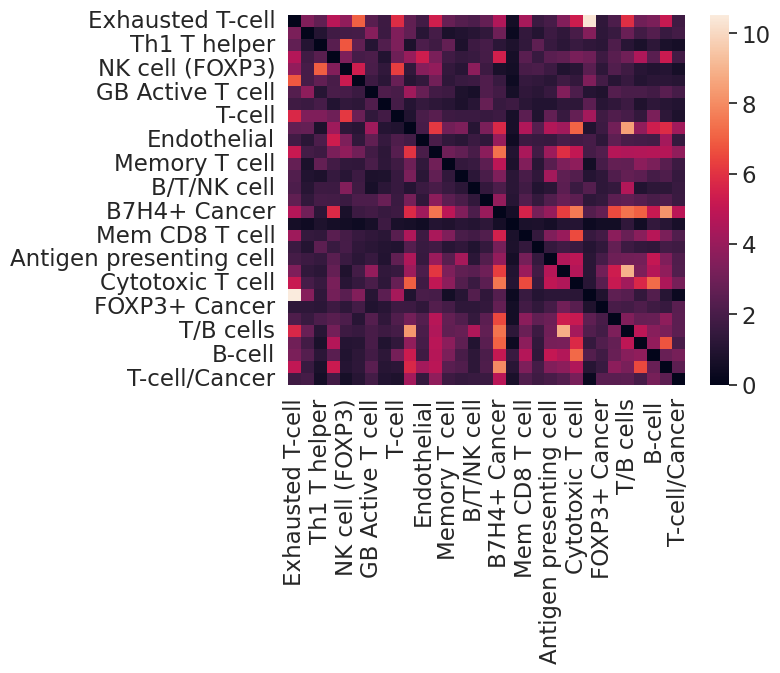

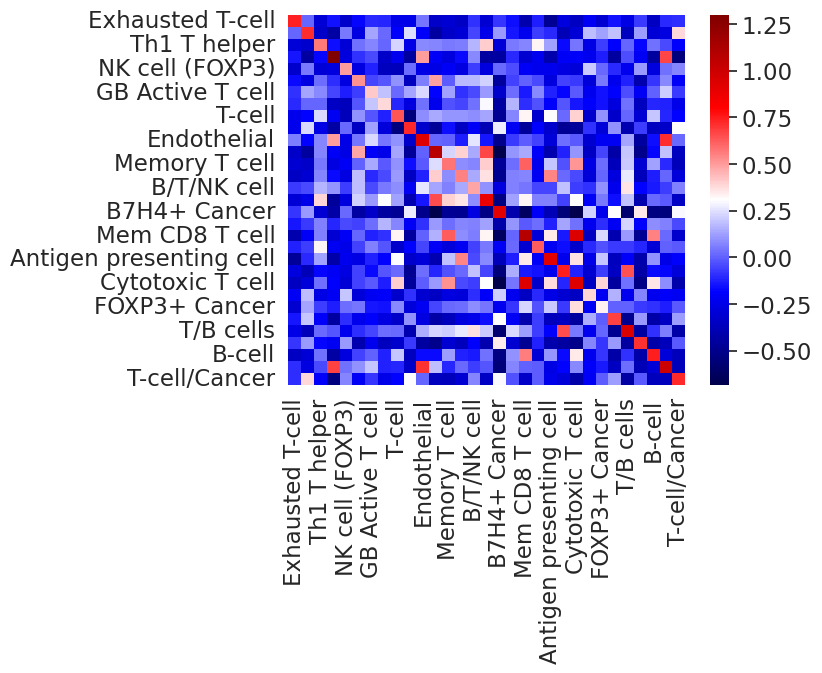

In [807]:
A = pd.DataFrame(np.nanstd(X,axis = 0),index = labels_list,columns=labels_list)#variable in cell cell contact
np.fill_diagonal(A.values,0)
sns.heatmap(A)
plt.figure()
sns.heatmap(pd.DataFrame(np.nanmean(X,axis = 0)/np.nanstd(X,axis = 0),index = labels_list,columns=labels_list),cmap='seismic')


# statistics of enrichment for non responder
after treatment



In [639]:
pd.Series(adata.obs['Pixie'].cat.categories).sort_values()

0         Alfa-SMA+ Monocytes
1     Antigen presenting cell
2                      B-cell
3                 B/T/NK cell
4                B7H4+ Cancer
5        B7H4+ Cancer (CD11b)
6                         CAF
7                  CD44+ MAC 
8            Cancer stem cell
9            Cytotoxic T cell
10               E-Cad cancer
11                Endothelial
12           Exhausted T-cell
13              FOXP3+ Cancer
14           GB Active T cell
15              Immune/Cancer
16                 Macrophage
17             Mem CD8 T cell
18              Memory T cell
19             Monocyte (HLA)
20            Monocyte (Tbet)
21                  Monocytes
22            NK cell (FOXP3)
23          NK cells / Cancer
24               PanCK Cancer
25                 Reg T-cell
26                     T-cell
27              T-cell/Cancer
28                  T/B cells
29               Th1 T helper
30           Vim+ Cancer / NK
dtype: object

In [208]:
dic = defaultdict(list)
key0 = 'B7-H4+ cancer'#'CD163+ MAC'#'Fibroblast'#'Cancer'#'B7-H4+ Cancer' #

'''
types_to_inspect = ['Activated T-cell', 'B7-H4+ cancer', 'CD163+ MAC', 'Cancer / NK',
       'Denditric', 'Endothelial cell', 'Fibroblast', 'Immune cell',
       'Immune cell / Fibroblast', 'Int Monocyte', 'Macrophage',
       'Mem B-cell', 'Mem CD8+ T-cell', 'Mem T-cell', 'NK / Immune',
       'NK T cell', 'NK cell / B7-H4 cancer', 'Naive T-cell',
       'Neutrophil & Monocyte', 'Neutrophil / B7-H4', 'NonCI Monocyte',
       'Reg T-cell']
'''
types_to_inspect = np.array(adata.obs['Pixie'].cat.categories)
def distance_dictionary(key0,adata,types_to_inspect=None,by_response_status = True):
    interval = np.linspace(0,1200,30)
    def make_dic(adata,acquisition_list,key0,types_to_inspect):
        dic =defaultdict(list)
        for ID in  tqdm(acquisition_list):
            sub_adata = adata[adata.obs.acquisition_ID==ID].copy()
            a = np.array(sub_adata.obs['Pixie'].cat.categories)#label list

            if ((key0 in a)& np.isin(types_to_inspect,a).any()): 
                #if there is at least a cell to inspect
                sq.gr.co_occurrence(sub_adata, cluster_key="Pixie",n_splits=1,interval=interval,show_progress_bar=False)
                x = sub_adata.uns['Pixie_co_occurrence']['interval'][1:]
                cooccur = np.squeeze(sub_adata.uns['Pixie_co_occurrence']['occ'][np.arange(len(a))[a==key0]])
                for key in types_to_inspect:
                    if (key in a):
                        y = np.squeeze(cooccur[a ==key])
                        dic[key]+=[y]

        return dic

    if types_to_inspect is None:
        types_to_inspect = adata.obs.Pixie.unique()
   

    if by_response_status == True:
        a = {}
        response_acq_ID = pd.DataFrame([*adata.obs[['Response','acquisition_ID']].value_counts().index],columns = ['Response','acquisition_ID'])
        for response_status,index in response_acq_ID.groupby('Response').groups.items():
            a[response_status] = make_dic(adata,response_acq_ID.loc[index].acquisition_ID,key0,types_to_inspect)
        return a['pCR'],a['Non-Responder'],interval
    else:
        return make_dic(adata,adata.obs.acquisition_ID.unique(),key0,types_to_inspect),interval
core = adata[adata.obs['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE']


Line below reads the distance distribution generated by the python script ```distance_distribution.py```. After this cell, you can load from the disk

**It takes few hours!** 

In [550]:
import pickle 

In [551]:
with open('distance_distribution.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)

In [552]:
dic_resection = loaded_dict['resection']
dic_pCR = loaded_dict['pCR']
dic_nR = loaded_dict['non_responder']
x = loaded_dict['x']

In [553]:
dic_resection.keys()

dict_keys(['Alfa-SMA+ Monocytes', 'Antigen presenting cell', 'B-cell', 'B/T/NK cell', 'B7H4+ Cancer', 'B7H4+ Cancer (CD11b)', 'CAF', 'CD44+ MAC ', 'Cancer stem cell', 'Cytotoxic T cell', 'E-Cad cancer', 'Endothelial', 'Exhausted T-cell', 'FOXP3+ Cancer', 'GB Active T cell', 'Immune/Cancer', 'Macrophage', 'Mem CD8 T cell', 'Memory T cell', 'Monocyte (HLA)', 'Monocyte (Tbet)', 'Monocytes', 'NK cell (FOXP3)', 'NK cells / Cancer', 'PanCK Cancer', 'Reg T-cell', 'T-cell', 'T-cell/Cancer', 'T/B cells', 'Th1 T helper', 'Vim+ Cancer / NK'])

key0 is the cell type we compute the 

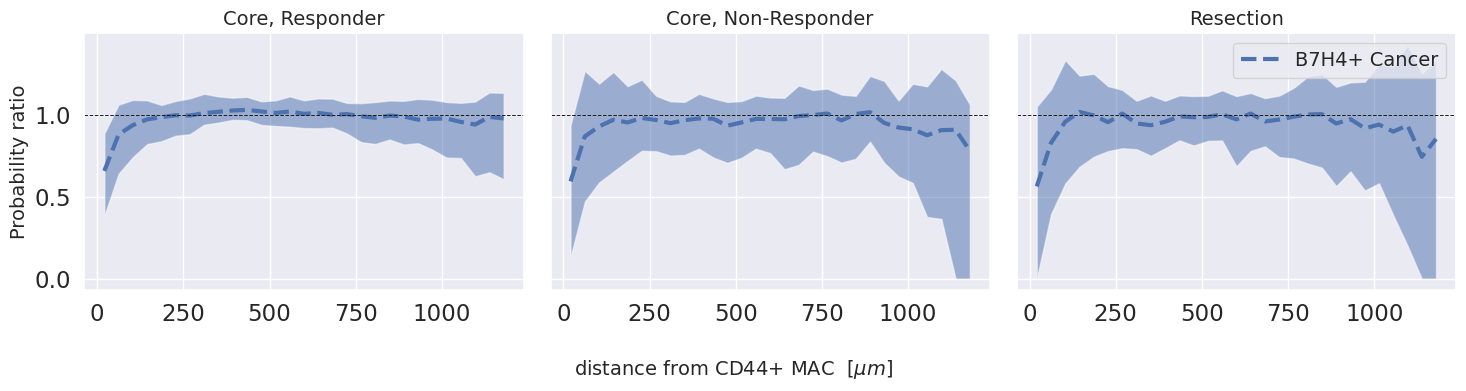

In [643]:
key0 = 'CD44+ MAC '#'Fibroblast'#'CD163+ MAC'
dic_resection_key0 = dic_resection[key0]
dic_pCR_key0  = dic_pCR[key0]
dic_nR_key0 = dic_nR[key0]
f,axs = plt.subplots(ncols=3,nrows=1,figsize = (15,4),sharey=True)
for key in  ['B7H4+ Cancer']:
    #
    #responders
    axs[0].plot((x[1:]+x[:-1])/2,np.nanmedian(dic_pCR_key0[key],axis = 0),label = key,ls = '--',lw = 3)
    q75, q25 = np.nanpercentile(dic_pCR_key0[key], [75 ,25],axis = 0)
    axs[0].fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)
    axs[0].set_title('Core, Responder',fontsize = 14)
    axs[1].plot((x[1:]+x[:-1])/2,np.nanmedian(dic_nR_key0[key],axis = 0),label = key,ls = '--',lw = 3)
    q75, q25 = np.nanpercentile(dic_nR_key0[key], [75 ,25],axis = 0)
    axs[1].fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)
    axs[1].set_title('Core, Non-Responder',fontsize = 14)
    axs[2].plot((x[1:]+x[:-1])/2,np.nanmedian(dic_resection_key0[key],axis = 0),label = key,ls = '--',lw = 3)
    q75, q25 = np.nanpercentile(dic_resection_key0[key], [75 ,25],axis = 0)
    axs[2].fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)
    axs[2].set_title('Resection',fontsize = 14)
    axs[0].axhline(1,ls = '--',c = 'k',lw = 0.7)
    axs[1].axhline(1,ls = '--',c = 'k',lw = 0.7)
    axs[2].axhline(1,ls = '--',c = 'k',lw = 0.7)
plt.xlabel(' ')
plt.legend(loc = 'lower right')
plt.tight_layout()
#axs[0].set_ylabel('$\\frac{P(X|\mathrm{CD163^+MAC})}{P(X)}$',fontsize = 16)
axs[0].set_ylabel('Probability ratio',fontsize = 14)

f.text(0.5, 0.02, 'distance from '+key0+' [$\mu m$]', ha='center',fontsize = 14)
#f.text(0.5, 0.02, 'distance from $\mathrm{CD163^+MAC}$ [$\mu m$]', ha='center',fontsize = 14)
#f.text(0.5, 0.96,'$P(X|\mathrm{CD163})/P(X)$',fontsize = 14)

plt.legend(fontsize = 14)
plt.tight_layout()
#plt.savefig(output_fig+'/spatial/co_occurrence_CD163Mac.png')
plt.show()

In [148]:
axs[0].axhline()

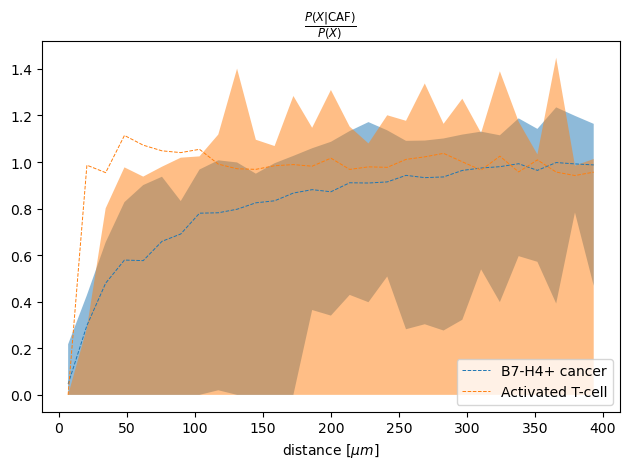

In [94]:
for key in ['B7-H4+ cancer','Activated T-cell']:#['Macrophage','B7-H4+ cancer']:
    plt.plot((x[1:]+x[:-1])/2,np.nanmedian(dic_resection[key],axis = 0),label = key,ls = '--',lw = 0.7)
    q75, q25 = np.nanpercentile(dic_nR[key], [75 ,25],axis = 0)
    plt.fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)

plt.xlabel('distance [$\mu m$]')
plt.title('$\\frac{P(X|\mathrm{CAF})}{P(X)}$')
plt.legend(loc = 'lower right')
plt.tight_layout()


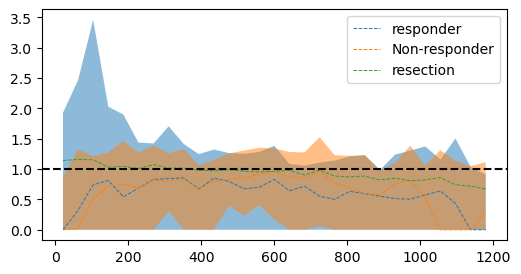

In [11]:
plt.figure(figsize = (6,3))
key = 'Activated T-cell'
plt.plot((x[1:]+x[:-1])/2,np.nanmedian(dic_pCR_key0[key],axis = 0),ls = '--',lw = 0.7,label = 'responder')
q75, q25 = np.nanpercentile(dic_pCR_key0[key], [75 ,25],axis = 0)
plt.fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)
plt.plot((x[1:]+x[:-1])/2,np.nanmedian(dic_nR_key0[key],axis = 0),ls = '--',lw = 0.7,label = 'Non-responder')
q75, q25 = np.nanpercentile(dic_nR_key0[key], [75 ,25],axis = 0)
plt.fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)
plt.plot((x[1:]+x[:-1])/2,np.nanmedian(dic_resection_key0[key],axis = 0),ls = '--',lw = 0.7,label = 'resection')
plt.legend()
#plt.fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)
plt.axhline(1,ls = '--',c = 'k')


In [85]:
#print(len(dic_nR[key]),len(dic_pCR[key]),len(dic_resection[key]))
a = adata.obs[['acquisition_ID','SAMPLE_TYPE_(CORE/RESECTION)','Response']].drop_duplicates().groupby(by = ['SAMPLE_TYPE_(CORE/RESECTION)','Response']).count()['acquisition_ID']
len(dic_pCR[key])/a.loc['CORE','pCR'],len(dic_nR[key])/a.loc['CORE','Non-Responder'],len(dic_resection[key])/a.loc['RESECTION','Non-Responder']

(0.6075949367088608, 0.5862068965517241, 0.544891640866873)

/home/giuseppe/anaconda3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


ValueError: x and y must have same first dimension, but have shapes (29,) and (1,)

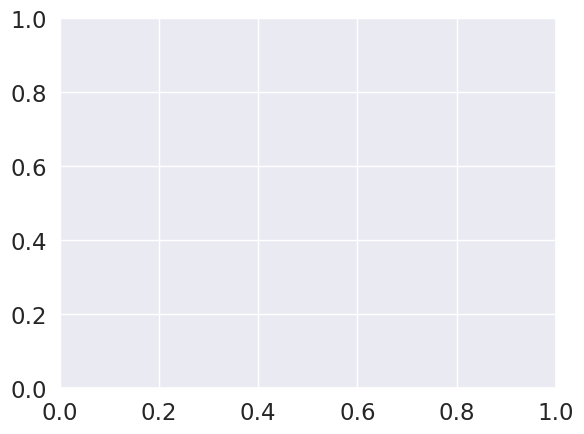

In [62]:
keys = ['CD8+ T-cell','CD4+ T-cell','NK cells PD-L1+']
for key in keys:
    plt.plot((x[1:]+x[:-1])/2,np.nanmedian(dic_pCR[key],axis = 0),label = key,ls = '--',lw = 0.7)
    q75, q25 = np.nanpercentile(dic_pCR[key], [75 ,25],axis = 0)
    plt.fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)

plt.xlabel('distance [$\mu m$]')
plt.title('$\\frac{P(X|\mathrm{Cancer B7}^-\mathrm{H4}^+)}{P(X)}$')
plt.legend(loc = 'lower right')
plt.tight_layout()
plt.figure()
for key in keys:
    plt.plot((x[1:]+x[:-1])/2,np.nanmedian(dic_nR[key],axis = 0),label = key,ls = '--',lw = 0.7)
    q75, q25 = np.nanpercentile(dic_nR[key], [75 ,25],axis = 0)
    plt.fill_between((x[1:]+x[:-1])/2,q75,q25,alpha = 0.5)


View of AnnData object with n_obs × n_vars = 3910892 × 39
    obs: 'Pixie', 'acquisition_ID', 'Leap_ID', 'SLIDE_NUMBER', 'BIOBANK_ID', 'SAMPLE_TYPE_(CORE/RESECTION)', 'FORMAT_(FFPE/FROZEN)', 'FORCE_TRIAL?_(Y/N)', 'DATE_SECTIONED', 'H&E_NOTES', 'ST_NOTES', 'Response', 'COMMENTS', 'qc_pass'
    obsm: 'spatial'

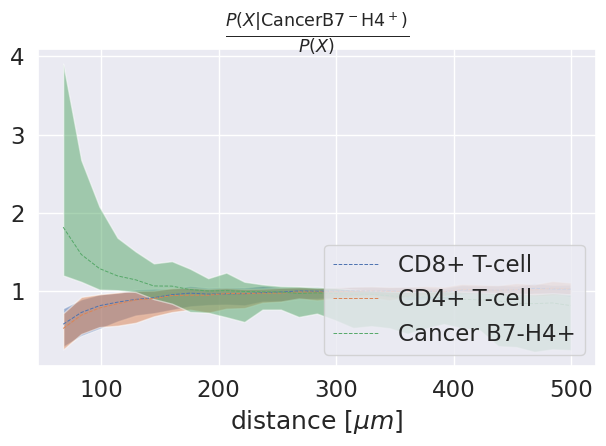

In [281]:
for key in ['CD8+ T-cell','CD4+ T-cell','Cancer B7-H4+']:
    plt.plot(x,np.nanmedian(dic[key],axis = 0),label = key,ls = '--',lw = 0.7)
    q75, q25 = np.nanpercentile(dic[key], [75 ,25],axis = 0)
    plt.fill_between(x,q75,q25,alpha = 0.5)

plt.xlabel('distance [$\mu m$]')
plt.title('$\\frac{P(X|\mathrm{Cancer B7}^-\mathrm{H4}^+)}{P(X)}$')
plt.legend(loc = 'lower right')
plt.tight_layout()
#plt.savefig(output_fig+'/spatial/co_occurrence_Tcells.png')

In [282]:
dic2 = defaultdict(list)
key2 = 'Fibroblasts' #'Cancer'


types_to_inspect = ['*B7-H4 - p53', 'CD11b MAC + VEGF', 'CD163+ MAC', 'CD4+ T-cell',
       'CD68+ MAC PD', 'CD8+ T-cell', 'Cancer', 'Cancer B7-H4+', 'EGFR',
       'Endothelial cells', 'Fibroblasts', 'Fibrocytes', 'Memory B-cell',
       'Memory CD8 T-cell', 'Monocyte CD16+', 'NK & CD8 T-cell col+vim',
       'NK cells PD-L1+', 'NK cells p53+', 'Naive B-cells',
       'Neutrophil & Monocyte']
for ID in  tqdm(adata.obs.acquisition_ID.unique()):
    sub_adata = adata[adata.obs.acquisition_ID==ID].copy()
    a = np.array(sub_adata.obs['Pixie'].cat.categories)#label list

    if ((key2 in a)& np.isin(types_to_inspect,a).any()): 
        #if there is at least a cell to inspect
        sq.gr.co_occurrence(sub_adata, cluster_key="Pixie",n_splits=1,interval=30)
        x = sub_adata.uns['Pixie_co_occurrence']['interval'][1:]
        cooccur = np.squeeze(sub_adata.uns['Pixie_co_occurrence']['occ'][np.arange(len(a))[a==key2]])
        for key in types_to_inspect:
            if (key in a):
                y = np.squeeze(cooccur[a ==key])
                dic2[key]+=[y]







  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.15s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.06s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.05/s]




  0

  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.42s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.00/s]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.87/s]




  0%|  

  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.20/s]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.06s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.17s/]




  0%|  

  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.39s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.86s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.65/s]




  0%|  

  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:07<00:00,  7.50s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:03<00:00,  3.12s/]




  0%|                                                                                                                                        | 0/1 [00:00<?, ?/s]



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.37s/]




  0%|  

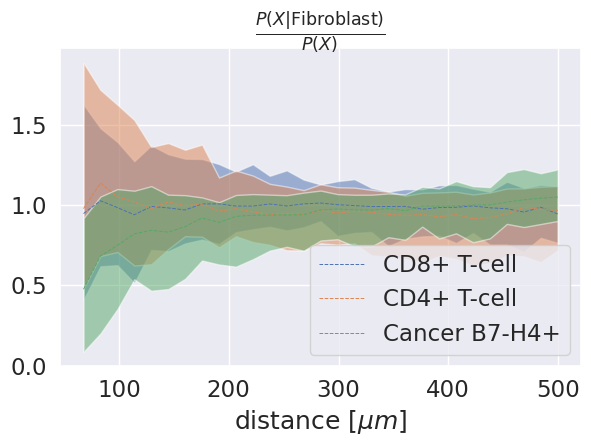

In [289]:
for key in ['CD8+ T-cell','CD4+ T-cell','Cancer B7-H4+']:
    plt.plot(x,np.nanmedian(dic2[key],axis = 0),label = key,ls = '--',lw = 0.7)
    q75, q25 = np.nanpercentile(dic2[key], [75 ,25],axis = 0)
    plt.fill_between(x,q75,q25,alpha = 0.5)

plt.xlabel('distance [$\mu m$]')
plt.title('$\\frac{P(X|\mathrm{Fibroblast})}{P(X)}$')
plt.legend(loc = 'lower right')
plt.tight_layout()
#plt.savefig(output_fig+'/spatial/co_occurrence_Tcells.png')

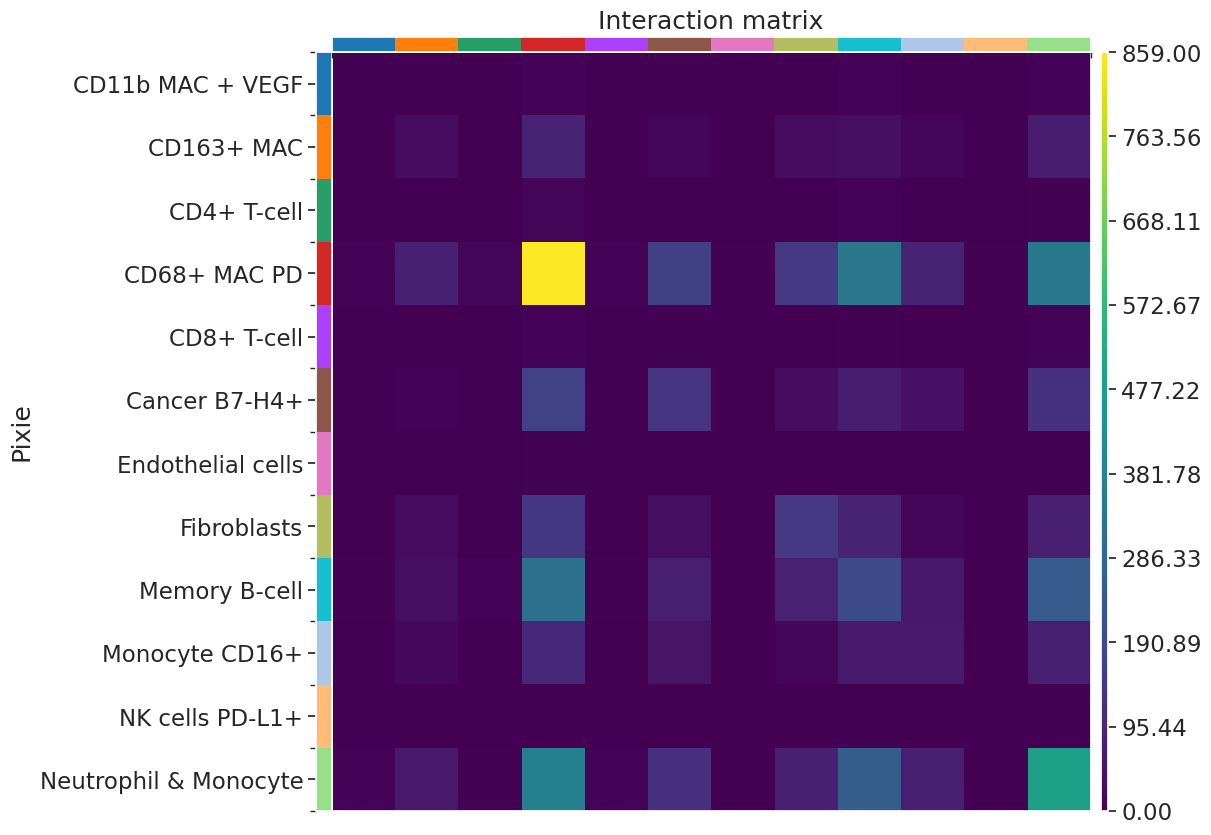

In [277]:
sq.gr.spatial_neighbors(sub_adata)

sq.gr.interaction_matrix(sub_adata, cluster_key="Pixie")
sq.pl.interaction_matrix(sub_adata, cluster_key="Pixie")

before treatment

In [171]:
dic = defaultdict(list)
for ID in ['Leap001_010', 'Leap001_009', 'Leap001_008']:
    sub_adata = adata[adata.obs.slice_ID==ID]
    a = np.array(sub_adata.obs['AnnoSpat'].cat.categories)#label list

    key0 = 'Naive CD8 T cells'
    key1 =  'Regulatory T cells'
    key2 = 'Naive B cells'
    if ((key0 in a)&((key1 in a) | (key2 in a))): 
        sq.gr.co_occurrence(sub_adata, cluster_key="AnnoSpat",n_splits=1)
        x = sub_adata.uns['AnnoSpat_co_occurrence']['interval'][1:]

        if (key1 in a):
            y1 = np.squeeze(np.squeeze(sub_adata.uns['AnnoSpat_co_occurrence']['occ'][np.arange(len(a))[a==key0]])[a ==key1])
            dic[key1]+=[y1]
        if (key2 in a):
            y2 = np.squeeze(np.squeeze(sub_adata.uns['AnnoSpat_co_occurrence']['occ'][np.arange(len(a))[a==key0]])[a == key2])
            dic[key2]+=[y2]

  0%|          | 0/1 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


  0%|          | 0/1 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


  0%|          | 0/1 [00:00<?, ?/s]

/home/giuseppe/anaconda3/lib/python3.8/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


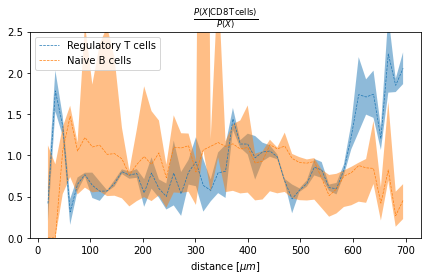

In [172]:
plt.plot(x,np.median(dic[key1],axis = 0),label = key1,ls = '--',lw = 0.7)
q75, q25 = np.percentile(dic[key1], [75 ,25],axis = 0)
plt.fill_between(x,q75,q25,alpha = 0.5)

plt.plot(x,np.median(dic[key2],axis = 0),label = key2,ls = '--',lw = 0.7)
q75, q25 = np.percentile(dic[key2], [75 ,25],axis = 0)
plt.fill_between(x,q75,q25,alpha = 0.5)
plt.xlabel('distance [$\mu m$]')
plt.title('$\\frac{P(X|\mathrm{CD8 \,T cells})}{P(X)}$')
plt.legend()
plt.tight_layout()
plt.ylim(0,2.5)
#plt.savefig(output_fig+'/co_occurrence_B_Tcells_before.png')

In [281]:
sq.gr.interaction_matrix(sub_adata, cluster_key="Pixie")

KeyError: "Spatial connectivity key `spatial_connectivities` not found in `adata.obsp`. Please run `squidpy.gr.spatial_neighbors(..., key_added='spatial')` first."

ERROR: Unable to fetch palette, reason: 'AnnoSpat_colors'. Using `None`.


<ipython-input-124-452c79bfe22b>:7: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.tight_layout()


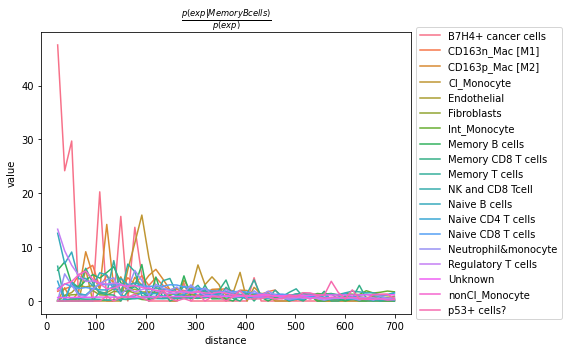

In [124]:
sq.pl.co_occurrence(
    sub_adata,
    cluster_key="AnnoSpat",
    clusters=['Memory B cells'],
    figsize=(8, 5),
)
plt.tight_layout()
#plt.savefig(output_fig+'/co_occurrence_all.png')

ERROR: Unable to fetch palette, reason: 'AnnoSpat_colors'. Using `None`.


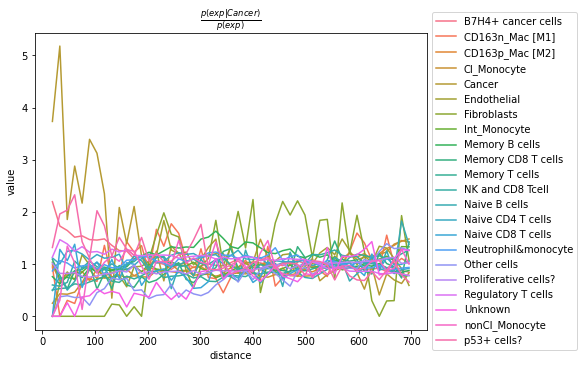

In [185]:
sq.pl.co_occurrence(
    ROI_1,
    cluster_key="AnnoSpat",
    clusters=['Cancer'],
    figsize=(8, 5),
)

In [21]:
cell_type_totals = pd.read_csv('../IMC_SegmentationResults/IMCCelltypeResults/CellTypeTotals.csv')
cell_type_totals.head()

,Image,CellType,Total,Density,Total_highProb,Density_highProb,Area_highProb,Max_probability_area,Max_probability_area_percentage
0,Leap001_ROI_001,Cancer,140.336744,0.000122,0.000000,0.000000,0.000000,0,0.000000
1,Leap001_ROI_001,CD163p_Mac..M2.,1726.340928,0.001505,31.445619,0.000027,0.000172,37,0.003226
2,Leap001_ROI_001,CD163n_Mac..M1.,6245.313083,0.005446,1.636302,0.000001,0.000013,4,0.000349
3,Leap001_ROI_001,Naive.CD4.T.cells,18.398982,0.000016,3.855173,0.000003,0.000022,7,0.000610
4,Leap001_ROI_001,Memory.T.cells,6.909340,0.000006,1.678131,0.000001,0.000010,2,0.000174


In [204]:
sc.pl.dotplot(adata, var_names = marker_list, groupby = groupby,return_fig=True)

source_file  ROI
Leap001_008  1      11285
Leap002_007  2       8471
Leap002_006  3       7998
Leap002_004  5       7486
Leap002_005  4       7418
Leap002_003  7       6399
Leap001_009  2       4741
Leap001_010  3       4233
dtype: int64

In [81]:
!conda remove pandas

Solving environment: failed

PackagesNotFoundError: The following packages are missing from the target environment:
  - pandas




In [23]:
cell_table_path='../../segmentation/cell_table_Denoised/cell_table_size_normalized_cell_labels.csv'
biosamples_path='../../IMC_data/ExtraDocs/processed_response.csv'
cell_table = pd.read_csv(cell_table_path,index_col=0)
biosamples =pd.read_csv(biosamples_path)

In [26]:
a = pd.DataFrame()
a['acquisition_ID'] = cell_table.fov.values
a['Leap_ID'] = a.acquisition_ID.str.split('_',n = 1).str[0].str.upper()
a['Leap_ID'] = a.Leap_ID.str[:7]#leap_ID should be Leap123, anything more is stripped
a = a.reset_index().merge(biosamples,left_on='Leap_ID',right_on= 'LEAP_ID').drop(['LEAP_ID'],axis = 1).set_index('index')


,cell_size,Alpha-SMA,B7-H4,Beta-Catenin,CD107a,CD11b,CD14,CD16,CD163,CD20,...,major_minor_axis_ratio_nuclear,perim_square_over_area_nuclear,major_axis_equiv_diam_ratio_nuclear,convex_hull_resid_nuclear,centroid_dif_nuclear,num_concavities_nuclear,nc_ratio_nuclear,fov,qc_pass,cell_meta_cluster
0,20.0,9.719178,2.562156,0.841030,2.111613,6.085198,4.050727,1.285434,1.266177,0.078927,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,Leap001_10,True,Exhausted T-cell
1,23.0,2.024567,3.809924,0.659187,7.519738,5.597603,7.389085,2.442718,4.658524,0.088660,...,1.732051,5.422792,1.227992,0.000000,0.000000,0.0,0.217391,Leap001_10,True,Exhausted T-cell
2,28.0,0.522883,1.674263,0.237865,0.242442,1.747659,1.450499,0.269629,0.084802,0.047948,...,2.977098,13.866414,1.693517,0.000000,0.000000,0.0,0.857143,Leap001_10,True,Immune/Cancer
3,18.0,1.680416,4.405127,0.964557,9.430544,7.080676,11.446597,2.798192,2.149114,0.035954,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,Leap001_10,False,Exhausted T-cell
4,22.0,0.896145,1.593253,0.428368,0.260594,2.662429,1.387367,0.056914,0.078898,0.034584,...,2.366055,11.572750,1.515735,0.000000,0.000000,0.0,0.863636,Leap001_10,True,Exhausted T-cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3738841,32.0,24.033463,2.490983,5.323712,4.240188,1.803764,5.417769,2.519558,1.129579,0.372089,...,1.691153,9.019603,1.279007,0.000000,0.000000,0.0,0.406250,Leap105_9,True,Reg T-cell
3738842,27.0,14.061170,3.169505,5.576680,3.933241,2.417123,3.141952,3.731654,4.000418,0.442996,...,1.199915,9.058817,1.093305,0.000000,0.000000,0.0,0.555556,Leap105_9,True,Reg T-cell
3738843,39.0,4.036462,6.530240,7.835200,2.992965,3.003883,3.988725,1.556952,1.409223,0.407383,...,2.235161,11.942728,1.522102,0.071429,0.033638,0.0,0.666667,Leap105_9,False,Reg T-cell
3738844,39.0,1.379511,2.421340,4.865887,1.609517,1.144406,0.995157,0.657955,0.567621,0.246194,...,2.025479,10.285534,1.401248,0.000000,0.000000,0.0,0.410256,Leap105_9,True,Reg T-cell


In [30]:
cell_table[(a['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE')*(a.Response == 'Non-Responder')].to_csv('../../segmentation/cell_table_Denoised/cell_tb_by_group/nonresponder.csv')
cell_table[(a['SAMPLE_TYPE_(CORE/RESECTION)']=='CORE')*(a.Response == 'pCR')].to_csv('../../segmentation/cell_table_Denoised/cell_tb_by_group/pCR.csv')
cell_table[a['SAMPLE_TYPE_(CORE/RESECTION)']=='RESECTION'].to_csv('../../segmentation/cell_table_Denoised/cell_tb_by_group/resection.csv')


In [29]:
a.Response == 'Non-Responder'

index
0          Non-Responder
1          Non-Responder
2          Non-Responder
3          Non-Responder
4          Non-Responder
               ...      
3738841              pCR
3738842              pCR
3738843              pCR
3738844              pCR
3738845              pCR
Name: Response, Length: 3738846, dtype: object